# Loading

In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

In [144]:
BASEDIR = "../LOGS"

runs = pd.read_csv(os.path.join(BASEDIR, "runs.csv"))
search_info = pd.read_csv(os.path.join(BASEDIR, "search_settings.csv"))
dataset_info = pd.read_csv(os.path.join(BASEDIR, "dataset_settings.csv"))
index_info = pd.read_csv(os.path.join(BASEDIR, "index_settings.csv"))

# Join the three settings dataframes on dataset_file
info = search_info.join(dataset_info.set_index('dataset_file'), on='dataset_file', how='left', rsuffix='_dataset')
info = info.join(index_info.set_index('index_file'), on='index_file', how='left', rsuffix='_index')

# Join the two dataframes where runs['settings_id'] is the id of the search settings
df = pd.merge(runs, info, left_on='settings_id', right_on='id', how='left', suffixes=('_run', '_settings'))

print(df.columns)

df.head()

Index(['id_run', 'settings_id', 'query_id', 'query_length', 'query_channels',
       'result_set_ts_indices', 'result_set_ts_positions',
       'result_set_distances', 'num_leaves_visited', 'num_nodes_visited',
       'num_ts_examined', 'total_time_s', 'first_layer_time_s',
       'tree_traversal_time_s', 'io_time_s', 'ts_examination_time_s',
       'id_settings', 'index_file', 'dataset_file', 'ffts_file', 'query_file',
       'num_queries', 'query_type', 'r_range_r', 'knn_k', 'exact',
       'normalized', 'search_method', 'distance_measure', 'id_dataset',
       'series_length', 'num_channels', 'num_series', 'id_index',
       'dataset_file_index', 'ffts_file_index', 'l_min', 'l_max',
       'normalized_index', 'index_type', 'segment_length', 'pos_per_env',
       'first_layer_num_bits', 'leaf_capacity', 'breakpoint_strategy',
       'split_strategy', 'min_num_bits_on_tie', 'num_bits_limit',
       'indexing_time_s', 'fft_calc_time_s'],
      dtype='object')


,id_run,settings_id,query_id,query_length,query_channels,result_set_ts_indices,result_set_ts_positions,result_set_distances,num_leaves_visited,num_nodes_visited,...,segment_length,pos_per_env,first_layer_num_bits,leaf_capacity,breakpoint_strategy,split_strategy,min_num_bits_on_tie,num_bits_limit,indexing_time_s,fft_calc_time_s
0,0,0,0,512,1;0;1;1,1,322,0.318006,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,0,1,512,1;1;1;1,31,299,0.301724,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,0,2,1024,1;0;1;1,110,0,0.154127,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,0,3,730,1;1;1;1,171,154,0.316969,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0,4,1024,1;0;0;1,172,0,0.257429,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [145]:
# Infer necessary columns
ALGOS = ['BRUTE_FORCE', 'MASS', 'MULISSE']

# Algorithm -- dependent on combinations of search method and distance measure
def get_algorithm(row):
    search_method = row.search_method
    distance_measure = row.distance_measure
    ffts_precomputed = not pd.isna(row.ffts_file)

    if 'scan' in search_method and distance_measure == 'ed' and not ffts_precomputed:
        return 'BRUTE_FORCE'
    elif 'scan' in search_method and distance_measure == 'mass' and ffts_precomputed:
        return 'MASS'
    elif 'isax' in search_method and distance_measure == 'ed':
        return 'MULISSE_ED'
    elif 'isax' in search_method and distance_measure == 'mass' and ffts_precomputed:
        return 'MULISSE'
    else:
        return np.nan
    
df['algorithm'] = df.apply(get_algorithm, axis=1)

df['dataset'] = df.dataset_file.str.extract(r'(\w+).bin')

df['num_query_channels'] = df.query_channels.str.count('1')

df[['algorithm', 'dataset', 'num_query_channels']]

,algorithm,dataset,num_query_channels
0,BRUTE_FORCE,rwalk_N5000_C4_M1024,3
1,BRUTE_FORCE,rwalk_N5000_C4_M1024,4
2,BRUTE_FORCE,rwalk_N5000_C4_M1024,3
3,BRUTE_FORCE,rwalk_N5000_C4_M1024,4
4,BRUTE_FORCE,rwalk_N5000_C4_M1024,2
...,...,...,...
2095,MULISSE,rwalk_N5000_C4_M2048,2
2096,MULISSE,rwalk_N5000_C4_M2048,4
2097,MULISSE,rwalk_N5000_C4_M2048,4
2098,MULISSE,rwalk_N5000_C4_M2048,1


# Test

In [150]:
view = df[
    (df.algorithm.isna() == False) &
    (df.dataset == 'rwalk_N5000_C4_M2048') &
    ((~df.algorithm.str.contains("MULISSE")) | (df.query_length >= df.l_min))
]

view.groupby(['algorithm', 'query_length', 'num_query_channels']).size().unstack()

num_query_channels        1   2   3   4
algorithm  query_length                
MASS       1796          24  24  25  27
           1900          22  35  17  26
           2048          24  32  24  20
MULISSE    1796          24  24  25  27
           1900          22  35  17  26
           2048          24  32  24  20
MULISSE_ED 1796          24  24  25  27
           1900          22  35  17  26
           2048          24  32  24  20

In [151]:
view.groupby(['algorithm', 'query_length', 'num_query_channels']).total_time_s.median().unstack()

num_query_channels              1         2         3         4
algorithm  query_length                                        
MASS       1796          0.849403  1.415906  2.029608  3.016732
           1900          0.828993  1.479197  2.255573  2.941028
           2048          0.740702  1.449493  2.162687  3.379332
MULISSE    1796          0.053814  0.022080  0.019980  0.020801
           1900          0.034088  0.022193  0.019554  0.021733
           2048          0.035512  0.019492  0.018776  0.021152
MULISSE_ED 1796          0.082488  0.033682  0.022086  0.024903
           1900          0.044895  0.029242  0.022163  0.022510
           2048          0.016920  0.017224  0.018973  0.020453

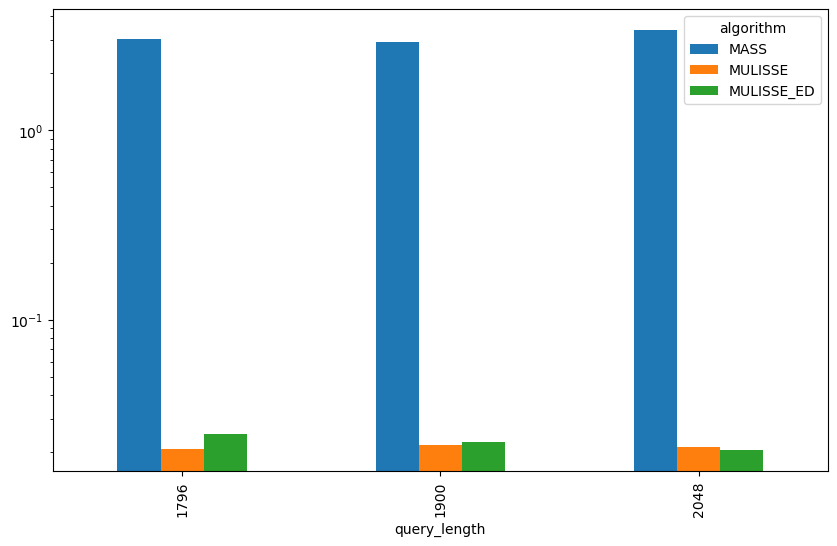

In [152]:
fig, ax = plt.subplots(figsize=(10, 6))

view[view['num_query_channels'] == 4].groupby(['query_length', "algorithm"]).total_time_s.median().unstack().plot(kind='bar', ax=ax)

ax.set_yscale("log")

In [153]:
view.groupby(['algorithm', 'query_length', 'num_query_channels']).num_ts_examined.median().unstack()

num_query_channels            1       2       3       4
algorithm  query_length                                
MASS       1796          5000.0  5000.0  5000.0  5000.0
           1900          5000.0  5000.0  5000.0  5000.0
           2048          5000.0  5000.0  5000.0  5000.0
MULISSE    1796           268.0    18.5     2.0     1.0
           1900           139.5    17.0     2.0     1.0
           2048           157.5     6.0     1.0     1.0
MULISSE_ED 1796           268.0    18.5     2.0     1.0
           1900           139.5    17.0     2.0     1.0
           2048           157.5     6.0     1.0     1.0